In [1]:
import os
import cv2
import numpy as np
import torch
import torch.utils.data
import torch.nn as nn
import yaml
import math
import copy
from tqdm import tqdm

from utils.general import non_max_suppression
from utils.augmentations import mix_augmentaion
from matplotlib import pyplot as plt
%matplotlib notebook 


In [2]:
#weight = 'static_model/best_288.pt'
#weight = 'static_model/best_726.pt'
#weight = 'static_model/best_3.pt'
#weight = 'static_model/best_299_my.pt'
#weight = 'static_model/last_22.pt'
#weight = 'static_model/last.pt'
#weight = 'static_model/last_genbg.pt'
#weight = 'static_model/epoch_049.pt'
weight = 'static_model/last_genbg_79.pt'
#weight = 'static_model/rotation_2.pt'
#weight = 'static_model/last_genbg_large_angle_79.pt'
#weight = 'static_model/real_word_049.pt'
#weight = 'static_model/real_word_079.pt'
#weight = 'static_model/CJ240126/5th2_set12_epoch_299.pt'
#weight = 'static_model/CJ240126/5th2_set1_best_268.pt'
#weight = 'static_model/CJ240126/5th2_set2_best_299.pt'
#weight = 'static_model/CJ240126/5th2_set3_best_260.pt'
#weight = 'static_model/CJ240126/exp2_new_best_271.pt'
#weight = 'static_model/CJ240126/exp2_new2_best_0.pt'
#weight = 'static_model/CJ240126/exp2_old_best_288.pt'


#weight = 'static_model/genbg_with_shadow_078.pt'
#weight = 'static_model/genbg_with_shadow_079.pt'









#label_txt = '/data/licence_plate/_plate/AOLP/label.txt'
#img_dir = '/data/licence_plate/_plate/AOLP/original/'


label_txt = '/data/licence_plate/_plate/weather/label.txt'
img_dir = '/data/licence_plate/_plate/weather/original/'

#label_txt = '/data/licence_plate/_plate/weather/label_with_extra.txt'
#img_dir = '/data/licence_plate/_plate/weather/original_with_extra/'

#label_txt = '/data/licence_plate/_plate/weather/label_with_extra_simple.txt'
#img_dir = '/data/licence_plate/_plate/weather/original_with_extra/'

#label_txt = '/data/licence_plate/_plate/weather/label_crop_with_extra.txt'
#img_dir = '/data/licence_plate/_plate/weather/crop_with_extra/'



#label_txt = '/data/licence_plate/_plate/generated_data/result2/label.txt'
#img_dir = '/data/licence_plate/_plate/generated_data/result2/img/'


data = 'data/plate.yaml'
input_size = 2048
diffusion_size = 1024
conf_thres = 0.5
iou_thres = 0.5
#conf_thres = 0.25
#iou_thres = 0.65
device = 'cuda:2'
#aug_licence = mix_augmentaion(noiseStepMode='exp')
aug_licence = mix_augmentaion()
aug_licence.imshape=(input_size,input_size)
aug_licence.random_parameter()
with open(data) as f:
    data = yaml.load(f, Loader=yaml.FullLoader)
classes = data['names']

In [3]:
checkpoint = torch.load(weight)
print(checkpoint.keys())
if 'epoch' in checkpoint.keys():
    print('Loaded {}, epoch {}'.format(weight, checkpoint['epoch']))
model = checkpoint['model'].cuda().to(device)#.half()

model.eval()
for param in model.parameters():
    param.requires_grad=False


#torch.save(model.state_dict(),'static_model/last_genbg_large_angle_79_state_dict.pt')
#torch.save(model.state_dict(),'static_model/real_word_079_state_dict.pt')
#torch.save(model.state_dict(),'static_model/CJ240126/exp2_old_best_288_state_dict.pt')
#torch.save(model.state_dict(),'static_model/CJ240126/exp2_new2_best_0_state_dict.pt')
#torch.save(model.state_dict(),'static_model/genbg_with_shadow_078_state_dict.pt')
#torch.save(model.state_dict(),'static_model/genbg_with_shadow_079_state_dict.pt')

#print(model.forward_two)

dict_keys(['epoch', 'best_fitness', 'training_results', 'model', 'ema', 'updates', 'optimizer', 'wandb_id'])
Loaded static_model/last_genbg_79.pt, epoch 79


In [4]:
from models.yolo_with_diffusion import Model_with_diffusion
cfgyolotiny='/data/licence_plate/_yolo/yolov7/cfg/training/yolov7-tiny.yaml'
hypyolotiny='/data/licence_plate/_yolo/yolov7/cfg/deploy/hyp.scratch.tiny.yaml'
#state_dict='static_model/best_288_state_dict.pt'
#state_dict='static_model/best_726_state_dict.pt'
#state_dict='static_model/best_3_state_dict.pt'
#state_dict='static_model/last_state_dict.pt'
#state_dict='static_model/last_genbg_state_dict.pt'
#state_dict='static_model/epoch_049_state_dict.pt'
state_dict='static_model/last_genbg_79_state_dict.pt'
#state_dict='static_model/real_word_049_state_dict.pt'
#state_dict='static_model/real_word_079_state_dict.pt'
#state_dict='static_model/last_genbg_large_angle_79_state_dict.pt'
#state_dict='static_model/CJ240126/exp2_new2_best_0_state_dict.pt'
#state_dict='static_model/genbg_with_shadow_078_state_dict.pt'
#state_dict='static_model/genbg_with_shadow_079_state_dict.pt'




#state_dict='static_model/last_22_state_dict.pt'
#state_dict='static_model/best_299_my_state_dict.pt'
nc=35
with open(hypyolotiny) as f:
    hyp = yaml.load(f, Loader=yaml.SafeLoader)  # load hyps

model = Model_with_diffusion(cfgyolotiny, ch=3, nc=nc, anchors=hyp.get('anchors')).to(device)#.half()  # create
model.load_state_dict(torch.load(state_dict))

model.eval()
for param in model.parameters():
    param.requires_grad=False


#print(model.m)


In [5]:
import sys
#sys.path.append('/data/licence_plate/Cold-Diffusion-Models/demixing-diffusion-pytorch/')

#from demixing_diffusion_pytorch.demixing_diffusion_licencepairs_pytorch import Unet, GaussianDiffusion, Trainer
#sys.path.append('/data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_pytorch/')
#from licenceplate_deaug_pytorch.licenceplate_deaug_pytorch_aug_in_dataloader import Unet, GaussianDiffusion, Trainer
work_path='/data/licence_plate/Cold-Diffusion-Models/'



#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_79k.pt'
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_125k.pt'

#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_135k.pt'
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_168k.pt'
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_213k.pt'### please set res to false
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_257k.pt'
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_304k.pt'
#model_path='/data/licence_plate/Cold-Diffusion-Models/model_image_2loss_325k.pt'


#cityscape_path='licenceplate_deaug_yolov7_pytorch/latent_yolov7_1024_2loss_image_cityscapes_res/'
#model_path=work_path+cityscape_path+'model_best_240000_0.899.pt'
#model_path=work_path+cityscape_path+'model_best_260000_0.900.pt'### please set res to True



#cityscape_path='licenceplate_deaug_yolov7_pytorch/latent_yolov7_1024_lastloss_image_cityscapes_res/'
#model_path=work_path+cityscape_path+'model_best_70000_0.865.pt'
#model_path=work_path+cityscape_path+'model_best_100000_0.872.pt'

cityscape_path='licenceplate_deaug_yolov7_2noise/yolov7_512_2loss_image_train/'
model_path=work_path+cityscape_path+'model_best_690000_0.905.pt'# change loading hist and change predict_noise to true

sys.path.append('/data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/')
from licenceplate_deaug_pytorch.licenceplate_deaug_pytorch_aug_in_dataloader_2noise import Unet, GaussianDiffusion, Trainer






data_path='/data/licence_plate/_plate/generated_data/result2/img/'


diffusionmodel = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels=3,
    with_time_emb=not(False),
    residual=False,
    predict_noise=True
).cuda()


#diffusionmodel = Unet(
#    dim = 64,
#    dim_mults = (1, 2, 4, 8),
#    channels=3,
#    with_time_emb=not(False),
#    residual=False
#).cuda().to(device)#.half()



diffusion = GaussianDiffusion(
    diffusionmodel,
    image_size = 512,
    device_of_kernel = 'cuda',
    channels = 3,
    timesteps = 100,        # number of steps
    loss_type = 'l1',                   # L1 or L2
    aug_routine='Default',
    train_routine = 'Final',
    sampling_routine = 'x0_step_down',
    yolomodel=model
).cuda().to(device)#.half()

diffusion = torch.nn.DataParallel(diffusion, device_ids=range(torch.cuda.device_count()))

diffusion_trainer = Trainer(
    diffusion,
    [data_path],
    image_size = 512,
    train_batch_size = 8,
    train_lr = 2e-5,
    train_num_steps = 700000, # total training steps
    gradient_accumulate_every = 2,      # gradient accumulation steps
    ema_decay = 0.995,                  # exponential moving average decay
    fp16 = False,                       # turn on mixed precision training with apex
    results_folder = './',
    load_path = model_path,
    dataset = 'AOLP',
    test_mode=True
)

for param in diffusion_trainer.model.parameters():
    param.requires_grad=False


#self.transform = transforms.Compose([
#    transforms.Resize((int(image_size*1.12), int(image_size*1.12))),
#    transforms.CenterCrop(image_size),
#    transforms.ToTensor(),
#    transforms.Lambda(lambda t: (t * 2) - 1)
#])

#def __len__(self):
#    return len(self.paths)

#def __getitem__(self, index):
#    path = self.paths[index]
#    path = os.path.join(path)
    #print(path+'\n')
#    index_img= path.find('/img/')
#    path_blur = path[:index_img]+'/img_blur/'+path[index_img+5:]

#    img = Image.open(path)
#    img = img.convert('RGB')
#    img_blur = Image.open(path_blur)
#    img_blur = img_blur.convert('RGB')
#    return self.transform(img),self.transform(img_blur)





#_,og_img = next(self.dl)
#og_img = og_img.cuda()


#X_0s, X_ts = self.ema_model.module.all_sample(batch_size=batches, img=og_img, times=s_times)

#og_img = (og_img + 1) * 0.5



Is Time embed used ?  True
(512, 512)
Loading :  /data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/yolov7_512_2loss_image_train/model_best_690000_0.905.pt
Step :  690000


In [6]:
def resize(img, size):
    h, w, c = img.shape
    if not (h == size and w == size):
        img = img.copy()
        scale_x = float(size / w)
        scale_y = float(size / h)
        ratio = min(scale_x, scale_y)
        nw, nh = int(w*ratio), int(h*ratio)
        new_img = cv2.resize(img, (nw, nh))

        blank = np.zeros((size, size, c))
        dw, dh = (size-nw)//2, (size-nh)//2
        blank[dh: dh+nh, dw: dw+nw] = new_img
        meta = {'nw': nw, 'nh': nh, 'dw': dw, 'dh': dh, 'w': w, 'h': h}
        return blank, meta
    else:
        meta = {}
        return img, meta
    
def getMetaFromHWC(h, w, c, size):
    if not (h == size and w == size):
        scale_x = float(size / w)
        scale_y = float(size / h)
        ratio = min(scale_x, scale_y)
        nw, nh = int(w*ratio), int(h*ratio)

        dw, dh = (size-nw)//2, (size-nh)//2
        meta = {'nw': nw, 'nh': nh, 'dw': dw, 'dh': dh, 'w': w, 'h': h}
        return  meta
    else:
        meta = {}
        return  meta

    
def resize_batch(img, size):
    #print(img.shape)
    #img_npy = x.cpu().numpy()
    new_img = [np.transpose(cv2.resize(np.transpose(x.cpu().numpy(),(1, 2, 0)), (size, size)),(2,0,1)) for x in img]
    new_img = torch.FloatTensor(np.array(new_img)).to(device)
    return new_img


def warp_affine(pt, M):
    new_pt = np.array([pt[0], pt[1], 1.], dtype=np.float32).T
    new_pt = np.dot(M, new_pt)
    return new_pt

def affine_transform(dets, meta):
    '''
    Transfer input-sized perdictions to original-sized coordinate. (Anchor)
    Input:
        dets = [1(batch), num_objs, 6(x1, y1, x2, y2, conf, cls)]
        meta = {'nw': resize_w, 
                'nh': resize_h, 
                'dw': offset_w, 
                'dh': offset_h, 
                'w': original_size_w, 
                'h': original_size_h}
    '''
    dets = np.array([x.cpu().numpy() for x in dets[0]])
    if len(meta)>0:
        p1 = np.float32([[0, 0], [0, meta['nh']], [meta['nw'], 0]])
        p2 = np.float32([[0, 0], [0, meta['h']], [meta['w'], 0]])
        M = cv2.getAffineTransform(p1, p2)

        for i in range(dets.shape[0]):
            dets[i, 0] -= meta['dw']
            dets[i, 1] -= meta['dh']
            dets[i, 2] -= meta['dw']
            dets[i, 3] -= meta['dh']

            dets[i, 0:2] = warp_affine(dets[i, 0:2], M)
            dets[i, 2:4] = warp_affine(dets[i, 2:4], M)
        return dets
    else:
        return dets

def preproccess_img(img_path):
    img = cv2.imread(img_path)
    img, meta = resize(img, input_size)
    img = (img / 255.).astype(np.float32)
    img = img[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, to 3x512x512
    #img = img[:, :, :].transpose(2, 0, 1)  # BGR to 3x512x512
    img = np.ascontiguousarray(img)
    img = torch.from_numpy(img).to(device)
    img = torch.unsqueeze(img, 0)
    #img = img.half()
    return img, meta

def run(img_path):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret = model(img)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

#X_0s, X_ts = self.ema_model.module.all_sample(batch_size=batches, img=og_img, times=s_times)
#step = torch.full((batch_size,), t - 1, dtype=torch.long).cuda()
#x1_bar = self.denoise_fn(img, step)
def diffusion_test(img_path,times=200):

    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        #ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        img_p = (img*2)-1
        batch_size = img_p.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        img_diffusion = diffusion_trainer.ema_model.module.denoise_fn(img_p,step)
        img_diffusion = (img_diffusion + 1) * 0.5

    return img, img_diffusion


def run_withdiffusion(img_path,times=100):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    #b,h,w,c=img.shape
    #print(meta)
    with torch.no_grad():
        img_diffusion_input = resize_batch(img,diffusion_size)
        #img_diffusion_input = img
        #img_diffusion_input = (img_diffusion_input*2)-1
        batch_size = img.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        
        img_diffusion = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
        #img_diffusion = (img_diffusion + 1) * 0.5
        img_diffusion = torch.clamp(img_diffusion, min=0.0, max=1.0)
        img_diffusion_output = resize_batch(img_diffusion,input_size)
        #img_diffusion_output = img_diffusion
        #h,w,c = [1024,1024,3]
        #meta = getMetaFromHWC(h,w,c,1024)
        #print(meta)

        ret = model(img_diffusion_output)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta



def run_withdiffusion_step(img_path,times=100,per_step=1):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    #b,h,w,c=img.shape
    #print(meta)
    with torch.no_grad():
        img_diffusion_input = img
        batch_size = img.shape[0]
        while(times>0):
            step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
            img_diffusion_input=img
            x0p = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
            x0p = torch.clamp(x0p, min=0.0, max=1.0)

            x_tm1 = aug_licence.batch_data_add_licence_aug(x0p,(times - 1-per_step)*0.01,clamp=True)

            times=times-per_step
            img=x_tm1

        
        img_diffusion_output = img

        ret = model(img_diffusion_output)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

def run_withdiffusion_step_img(img_path,times=100,per_step=1):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    #img = aug_licence.batch_data_add_licence_aug(img,(times - 1)*0.01,clamp=True)
    img_start=img
    #b,h,w,c=img.shape
    #print(meta)
    first_step=True
    all_img_x0p=[]
    all_img_xt=[]
    with torch.no_grad():
        #img_diffusion_input = img
        batch_size = img.shape[0]
        while(times>0):
            step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
            img_diffusion_input=img
            x0p = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
            x0p = torch.clamp(x0p, min=0.0, max=1.0)
            if first_step:
                direct_img=x0p
                first_step=False
            
            x_tm1 = aug_licence.batch_data_add_licence_aug(x0p,(times - 1-per_step)*0.01,clamp=True)
            x_tm1 = torch.clamp(x_tm1, min=0.0, max=1.0)

            
            all_img_xt.append(aug_licence.torchcuda2npy_cv2(x_tm1[0]))
            all_img_x0p.append(aug_licence.torchcuda2npy_cv2(x0p[0]))
            if times-per_step>0:
                times=times-per_step
                img=x_tm1
            else:
                times=times-per_step
                img=x0p
                
                
        
        img_diffusion_output = img
        
    return img_start, direct_img, img_diffusion_output, all_img_xt, all_img_x0p


def run_withdiffusion_step_cold_img(img_path,times=100,per_step=1):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img = aug_licence.batch_data_add_licence_aug(img,(times - 1)*0.01,clamp=True)
    img_start=img
    #b,h,w,c=img.shape
    #print(meta)
    first_step=True
    all_img_x0p=[]
    all_img_xt=[]
    with torch.no_grad():
        #img_diffusion_input = img
        batch_size = img.shape[0]
        while(times>0):
            step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
            img_diffusion_input=img
            x0p = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
            x0p = torch.clamp(x0p, min=0.0, max=1.0)
            if first_step:
                direct_img=x0p
                first_step=False
            
            x_tm1 = aug_licence.batch_data_add_licence_aug(x0p,(times - 1-per_step)*0.01,clamp=True)
            x_t = aug_licence.batch_data_add_licence_aug(x0p,(times - 1)*0.01,clamp=True)
            
            cold_tm1 = img_diffusion_input-x_t+x_tm1
            cold_tm1 = torch.clamp(cold_tm1, min=0.0, max=1.0)

            #cold_tm1=x0p

            all_img_xt.append(aug_licence.torchcuda2npy_cv2(cold_tm1[0]))
            all_img_x0p.append(aug_licence.torchcuda2npy_cv2(x0p[0]))
            #all_img_x0p.append(aug_licence.torchcuda2npy_cv2(cold_tm1[0]))
            if times-per_step>0:
                times=times-per_step
                img=cold_tm1
            else:
                times=times-per_step
                img=x0p
                
                
        
        img_diffusion_output = img
    img_start = aug_licence.torchcuda2npy_cv2(img_start[0])
    direct_img = aug_licence.torchcuda2npy_cv2(direct_img[0])
    img_diffusion_output = aug_licence.torchcuda2npy_cv2(img_diffusion_output[0])
    
    return img_start, direct_img, img_diffusion_output, all_img_xt, all_img_x0p

def run_aug_duffusion_img(img_path,times=100):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img_start=img
    all_img_xt=[]
    all_img_x0p=[]
    all_noise=[]
    #all_img.append(img)
    t=0
    with torch.no_grad():
        while(t<times):
            x_tm1 = aug_licence.batch_data_add_licence_aug(img,(t)*0.01,clamp=True)
            
            xt_np=aug_licence.torchcuda2npy_cv2(x_tm1[0])
            all_img_xt.append(xt_np)
            
            img_diffusion_input = resize_batch(x_tm1,diffusion_size)
            batch_size = x_tm1.shape[0]
            step = torch.full((batch_size,), t, dtype=torch.long).cuda().to(device)#.half()

            img_diffusion = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
            #img_diffusion = (img_diffusion + 1) * 0.5
            img_diffusion = torch.clamp(img_diffusion, min=0.0, max=1.0)
            img_diffusion_output = resize_batch(img_diffusion,input_size)
            
            
            x0p_np=aug_licence.torchcuda2npy_cv2(img_diffusion_output[0])
            all_img_x0p.append(x0p_np)
            all_noise.append(xt_np-x0p_np)
            t=t+1
            


    return all_img_xt, all_img_x0p, all_noise

def run_aug_img(img_path,times=100):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img_start=img
    all_img=[]
    all_noise=[]
    #all_img.append(img)
    index=0
    with torch.no_grad():
        while(index<times):
            x_tm1 = aug_licence.batch_data_add_licence_aug(img,index*0.01,clamp=True)
            index+=1
            
            
            noise=img-x_tm1
            x_tm1=aug_licence.torchcuda2npy_cv2(x_tm1[0])
            noise=aug_licence.torchcuda2npy_cv2(noise[0])
            all_img.append(x_tm1)
            all_noise.append(noise)
            print('index = %d/%d'%(index,times))
    return all_img, all_noise



def run_aug_withdiffusion(img_path,times=200,ratio=1.0):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img = aug_licence.batch_data_add_licence_aug(img, ratio)

    with torch.no_grad():
        #ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        #img_diffusion_input = resize_batch(img,diffusion_size)
        img_diffusion_input = img
        #img_diffusion_input = (img_diffusion_input*2)-1
        batch_size = img.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        img_diffusion = diffusion_trainer.ema_model.module.denoise_fn(img_diffusion_input,step)
        #img_diffusion = (img_diffusion + 1) * 0.5
        img_diffusion = torch.clamp(img_diffusion, min=0.0, max=1.0)
        #img_diffusion_output = resize_batch(img_diffusion,input_size)
        img_diffusion_output = img_diffusion

        ret = model(img_diffusion_output)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta



def run_aug(img_path,ratio=1.0):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    b, c, h, w = img.shape
    aug_licence.imshape=[h,w]
    aug_licence.random_parameter()

    img = aug_licence.batch_data_add_licence_aug(img, ratio)
    with torch.no_grad():
        ret = model(img)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

#==================================================================

def transfer_label(lab):
    '''
    Transfer label(string) into list(int).
    Input:
        lab: string list ['x_min,y_min,x_max,y_max,plate']
            i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        new_lab: int list [x_min, y_min, x_max, y_max]
            i.e. [[14,71,83,105], [215,188,324,240]]
    '''
    new_lab = []
    for l in lab:
        _l = l.split(',')
        x1 = int(_l[0])
        y1 = int(_l[1])
        x2 = int(_l[2])
        y2 = int(_l[3])
        new_lab.append([x1, y1, x2, y2])
    
    return new_lab

def get_iou(bb1, bb2):
    '''
    Input:
        bb1(groundtruth) = [left_top_x, y, right_bottom_x, y]
        bb2(predict_point) = [left_top_x, y, right_bottom_x, y]
    '''
    x_left = max(bb1[0], bb2[0])
    y_top = max(bb1[1], bb2[1])
    x_right = min(bb1[2], bb2[2])
    y_bottom = min(bb1[3], bb2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])

    iou = intersection_area / float(bb1_area + bb2_area - intersection_area)
    assert iou >= 0.0
    assert iou <= 1.0
    return iou

def check_bbox_old(bb1, bb2):
    '''
    Check if bb2 is completely covered by bb1.
    If so, return True, otherwise return False.
    Input:
        bb1(large region) = [x_min, y_min, x_max, y_max] (all int)
        bb2(small region) = [x_min, y_min, x_max, y_max] (all int)
    '''
    # Assert bb1 is the larger one
    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])
    if bb1_area < bb2_area:
        temp = bb2
        bb2 = bb1
        bb1 = temp
    
    f1 = bb1[0] <= bb2[0]
    f2 = bb1[1] <= bb2[1]
    f3 = bb1[2] >= bb2[2]
    f4 = bb1[3] >= bb2[3]

    if f1 and f2 and f3 and f4:
        return True
    else:
        return False
    
def check_bbox(bb1, bb2):
    '''
    Check if the center point of bb2 is within bb1.
    If so, return True, otherwise return False.
    Input:
        bb1(large region) = [x_min, y_min, x_max, y_max] (all int)
        bb2(small region) = [x_min, y_min, x_max, y_max] (all int)
    '''
    # Assert bb1 is the larger one
    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])
    if bb1_area < bb2_area:
        temp = bb2
        bb2 = bb1
        bb1 = temp
        
    b2cx = (bb2[0] + bb2[2]) / 2
    b2cy = (bb2[1] + bb2[3]) / 2
    
    f1 = (bb1[0] < b2cx < bb1[2])
    f2 = (bb1[1] < b2cy < bb1[3])
    if f1 and f2:
        return True
    else:
        return False
    
#     f1 = bb1[0] <= bb2[0]
#     f2 = bb1[1] <= bb2[1]
#     f3 = bb1[2] >= bb2[2]
#     f4 = bb1[3] >= bb2[3]

#     if f1 and f2 and f3 and f4:
#         return True
#     else:
#         return False


def group_plate(outp):
    '''
    Group each character into seperate plates.
    Input:
        outp = float[[x1, y1, x2, y2, score, class], ...]
            i.e. [[     40.859      162.66      142.42      216.09      0.9668          34]
                  [     125.08      178.28      138.83      208.91     0.93213           6]
                  [         95      176.41      110.94      207.03      0.9248           8]
                  [     110.16      177.34      125.16      208.28     0.91211           8]
                  [     80.156      175.47      97.344      206.72     0.90674           4]
                  [     45.039      173.44      64.414         205     0.89111          13]
                  [     60.078      174.06      78.828      205.62     0.81445          17]]
    Return: 
        a sorted list of dict [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, idx], ...]}, ...]
             i.e. [{'plate': [40, 162, 142, 216], 
                    'char':  [[45, 173, 64, 205, 13],
                             [60, 174, 78, 205, 17],
                             [80, 175, 97, 206, 4],
                             [95, 176, 110, 207, 8],
                             [110, 177, 125, 208, 8],
                             [125, 178, 138, 208, 6]]}]
    '''
    plates = []
    chars = []
    groups = []
    for obj in outp:
        if int(obj[-1]) == 34:
            pla = [int(p) for p in obj[:4]]
            group = {'plate': pla, 'char':[]}
            groups.append(group)
        else:
            chars.append(obj)
    for obj in chars:
        cha = [int(obj[0]), int(obj[1]), int(obj[2]), int(obj[3]), int(obj[5])]
        for g in groups:
            pla = g['plate']
            if check_bbox(pla, cha[:4]):
                g['char'].append(cha)
    ### Sort list
    for g in groups:
        g['char'] = sorted(g['char'], key=lambda x: x[0])
    return groups

def get_str(chars):
    '''
    Create plate string from indivisual detected character.
    Input:
        chars = a sorted list [int[x1, y1, x2, y2, idx], ...]]
    Return:
        plate_str = plate string, i.e. 'DH4886'
    '''
    s = ''
    for o in chars:
        c = o[-1]
        s += classes[c]
    return s

def get_acc(inp, outp):
    """
    Compute two strings character by character.
    Input:
        inp: ground truth(str)
        outp: detected result(str)
    Return:
        m: number of groundtruth(int)
        count: number of detect correctly(int)
    """
    m = len(inp)
    count = sum((Counter(inp) & Counter(outp)).values())
    return m, count

def compute_acc(outp, labels):
    '''
    Compute accuracy between detected results and labels.
    Input:
        outp = a list of dic [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, idx], ...]}, ...]
        labels = a list of str, i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        total = the number of all characters in labels
        correct = the number of correct-detected characters
    '''
    total = 0
    correct = 0
    for label in labels:
        line = label.split(',')
        plate_gt = [int(x) for x in line[:4]]
        for g in outp:
            if get_iou(plate_gt, g['plate']) >= 0.5:
                detected_plate = get_str(g['char'])
                t, c = get_acc(line[-1], detected_plate)
                total += t
                correct += c
    return total, correct

def labels_len(labels):
    '''
    Compute the number of characters in ground truth.
    Input:
        labels = a list of str, i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        num = the number of characters of all plates
    '''
    num = 0
    for label in labels:
        lines = label.split(',')
        n = len(lines[-1])
        num += n
    return num

def get_wer(r, h):
    """
    Compute word_error_rate(WER) of two list of strings.
    Input:
        r = ground truth
        h = predicted results
    Return:
        result = WER (presented in percentage)
        sid = substitution + insertion + deletion
        total = the number of groundtruth
    """
    d = np.zeros((len(r) + 1) * (len(h) + 1), dtype=np.uint16)
    d = d.reshape((len(r) + 1, len(h) + 1))
    for i in range(len(r) + 1):
        for j in range(len(h) + 1):
            if i == 0:
                d[0][j] = j
            elif j == 0:
                d[i][0] = i

    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                substitution = d[i - 1][j - 1] + 1
                insertion = d[i][j - 1] + 1
                deletion = d[i - 1][j] + 1
                d[i][j] = min(substitution, insertion, deletion)
    sid = d[len(r)][len(h)]
    total = len(r)
    result = float(sid) / total * 100

    return result, sid, total

def fliter_by_length(data):
    after_filter = []
    for x in data:
        if len(x['char'])>=2 and len(x['char'])<=7:
            after_filter.append(x)
    return after_filter


def eval_dataset(results,label_data,word_length_filter=False):
    correct_plate = {}
    total_p, correct_p, pred_p = 0, 0, 0
    for k, v in label_data.items():
        gt = transfer_label(v)
        #print(gt)
        total_p += len(gt)
        if k in results:
            r = group_plate(results[k]) # r = [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, label], ...]}, ...]
            if word_length_filter:
                r = fliter_by_length(r)
            pred_p += len(r)
            correct_r = []
            for _r in r:
                for idx, bbox in enumerate(gt):
                    if get_iou(bbox, _r['plate']) >= 0.5:
                        n_r = {'plate': _r['plate'], 'char': _r['char'], 'idx': idx}
                        correct_r.append(n_r)
            num = len(correct_r)
            if num > 0:
                correct_plate[k] = correct_r
                correct_p += num
    if not pred_p ==0:

        print("Number of Correctly Detected Plates =", correct_p)
        print("Number of Detected Plates =", pred_p)
        print("Number of All Plates =", total_p)
        print("Recall = {:.4f}".format(correct_p/total_p))
        print("Precision = {:.4f}".format(correct_p/pred_p))

        n_perfect = 0  ### number of perfectly recognized plates
        n_sid = 0  ### number of failed recognized chars in detected
        n_detected = 0  ### number of chars in detected plates
        filterout_gt = 0

        for k, v in label_data.items():
            gt_strs = [s.split(',')[-1] for s in v]
            for gt_str in gt_strs:
                if len(gt_str)<1 or len(gt_str)>7:
                    filterout_gt+=1
                    #print(gt_str)
            if k in correct_plate:
                objs = correct_plate[k]
                for obj in objs: # obj = [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, label], ...], 'idx': int(i)}]
                    pred_str = [classes[x[-1]] for x in obj['char']]
                    wer, sid, t = get_wer(list(gt_strs[obj['idx']]), pred_str)
                    n_sid += sid
                    n_detected += t
                    if wer == 0:
                        n_perfect += 1

        print("Filter out ground truth = ", filterout_gt)
        print("Characters in Detected Plates = ", n_detected)
        print("Error Characters (Detected) =", n_sid)
        print("World Error Rate (Detected) = {:.4f}".format(n_sid/n_detected))

        print("\nNumber of Perfectly Recognized Plates = ", n_perfect)
        print("Accuracy(Detected) = {:.4f}".format(n_perfect/correct_p))
        print("Accuracy(Groundtruth) = {:.4f}".format(n_perfect/total_p))

In [7]:
"""
Create label dictionary.
Format: dic = {key: file_name(str), value: [obj1(str), obj2(str), ...]}
        obj format = 'x_min, y_min, x_max, y_max, plate'
   i.e. dic['train_LE_3'] = ['266,199,350,242,2972KK']
        dic['train_LE_33'] = ['14,71,83,105,FS799', '215,188,324,240,DP4846']
"""
label_data = {}
#label_txt = '/data/licence_plate/_plate/AOLP/label.txt'
#label_txt = '/data/licence_plate/_plate/weather/label.txt'
#label_txt = '/data/licence_plate/_plate/generated_data/result2/label.txt'

label_file = open(label_txt, 'r')
lines = label_file.readlines()
for line in lines:
    l = line.strip().split(' ')
    name = l[0]
    plates = l[1:]
    label_data[name] = plates

In [8]:
#img_dir = '/data/licence_plate/_plate/AOLP/original/'
#img_dir = '/data/licence_plate/_plate/weather/original/'
#img_dir = '/data/licence_plate/_plate/generated_data/result2/img/'

img_paths = os.listdir(img_dir)
img_paths.sort()
model.create_subnetwork()
#model.before_diffusion_model.half()
#model.after_diffusion_model.half()

In [12]:
# test original network and after clip subnet should be all same(mean=max=min=0)
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret1, ret2, meta = run_test_bfaf(img_p)
        #print(ret1[1][0])
        #print(ret2[1][0])
        for idx_ret in range(len(ret1)):
            print(str(idx_ret)+'_'+str(torch.mean(ret1[idx_ret][0]-ret2[idx_ret][0]))+str(torch.min(ret1[idx_ret][0]-ret2[idx_ret][0]))+str(torch.max(ret1[idx_ret][0]-ret2[idx_ret][0])))
        break

  0%|                                                    | 0/47 [00:00<?, ?it/s]


NameError: name 'run_test_bfaf' is not defined

In [12]:
results = {}
eval_dataset(results,label_data)

[[168, 182, 247, 215]]
[[110, 185, 189, 219]]
[[141, 161, 212, 195]]
[[126, 142, 201, 175]]
[[52, 144, 127, 180]]
[[161, 162, 237, 196]]
[[20, 141, 97, 175]]
[[266, 187, 344, 219]]
[[92, 145, 168, 179]]
[[226, 161, 303, 197]]
[[135, 155, 213, 188]]
[[216, 148, 292, 181]]
[[224, 127, 301, 164]]
[[224, 188, 302, 219]]
[[74, 122, 149, 155]]
[[132, 167, 209, 200]]
[[166, 154, 240, 188]]
[[35, 167, 113, 200]]
[[218, 187, 298, 219]]
[[77, 188, 155, 220]]
[[107, 187, 187, 218]]
[[219, 159, 293, 191]]
[[173, 174, 251, 209]]
[[163, 156, 242, 191]]
[[104, 162, 180, 197]]
[[18, 168, 96, 203]]
[[155, 131, 232, 166]]
[[116, 142, 191, 178]]
[[53, 124, 128, 158]]
[[195, 182, 275, 217]]
[[103, 100, 176, 134]]
[[140, 123, 216, 157]]
[[180, 131, 257, 164]]
[[263, 167, 344, 203]]
[[128, 180, 208, 215]]
[[39, 146, 115, 180]]
[[197, 114, 272, 148]]
[[206, 181, 286, 217]]
[[225, 178, 304, 213]]
[[28, 130, 105, 164]]
[[132, 158, 208, 191]]
[[237, 137, 311, 174]]
[[0, 178, 77, 215]]
[[275, 162, 351, 197]]
[[7

## baseline

In [9]:
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'
print('yolo model_path= %s'%(weight))
print('input_size= %d'%(input_size))
print('label_txt= %s'%(label_txt))

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg') or f.endswith('.png'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p)
        
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
eval_dataset(results,label_data)

  0%|                                                  | 0/2049 [00:00<?, ?it/s]

yolo model_path= static_model/last_genbg_79.pt
input_size= 1024
label_txt= /data/licence_plate/_plate/AOLP/label.txt


100%|███████████████████████████████████████| 2049/2049 [01:38<00:00, 20.77it/s]


Number of Correctly Detected Plates = 2154
Number of Detected Plates = 3046
Number of All Plates = 2164
Recall = 0.9954
Precision = 0.7072
Filter out ground truth =  0
Characters in Detected Plates =  12857
Error Characters (Detected) = 423
World Error Rate (Detected) = 0.0329

Number of Perfectly Recognized Plates =  1854
Accuracy(Detected) = 0.8607
Accuracy(Groundtruth) = 0.8567


In [18]:
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p)
        
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
eval_dataset(results,label_data)

100%|███████████████████████████████████████████| 47/47 [00:25<00:00,  1.86it/s]

Number of Correctly Detected Plates = 28
Number of Detected Plates = 29
Number of All Plates = 54
Recall = 0.5185
Precision = 0.9655
Characters in Detected Plates =  180
Error Characters (Detected) = 60
World Error Rate (Detected) = 0.3333

Number of Perfectly Recognized Plates =  7
Accuracy(Detected) = 0.2500
Accuracy(Groundtruth) = 0.1296


In [10]:
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p)
        
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
            
print('yolo model_path= %s'%(weight))
print('input_size= %s'%(input_size))
print('diffusion_size= %s'%(diffusion_size))
print('model_path= %s'%(model_path))

eval_dataset(results,label_data)


100%|███████████████████████████████████████████| 47/47 [00:15<00:00,  3.00it/s]

yolo model_path= runs/train/exp5/best_726.pt
input_size= 2816
diffusion_size= 1536
model_path= /data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_pytorch/latent_yolov7_1024_2loss_image_cityscapes_res/model_best_240000_0.899.pt
Number of Correctly Detected Plates = 38
Number of Detected Plates = 70
Number of All Plates = 54
Recall = 0.7037
Precision = 0.5429
Characters in Detected Plates =  239
Error Characters (Detected) = 49
World Error Rate (Detected) = 0.2050

Number of Perfectly Recognized Plates =  15
Accuracy(Detected) = 0.3947
Accuracy(Groundtruth) = 0.2778


## w/diffusion

In [9]:

_t=[]
results_all=[]

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg') or f.endswith('.png'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p)
        
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
            
_t.append(-1)
results_all.append(results)

#for step_t in [0,50,100,150,200]:
for step_t in [0,12,25]:
    results_diffusion = {}
    for f in tqdm(img_paths, ncols=80):
        if f.endswith('.jpg') or f.endswith('.png'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            ret, meta = run_withdiffusion(img_p,times=step_t)
            
            if ret[0] is not None:
                #print(meta)
                output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
                results_diffusion[bname] = output
    _t.append(step_t)
    results_all.append(results_diffusion)


100%|███████████████████████████████████████████| 47/47 [01:02<00:00,  1.33s/it]


In [10]:
word_length_filter=True


print('yolo model_path= %s'%(weight))
print('input_size= %s'%(input_size))
print('diffusion_size= %s'%(diffusion_size))
print('model_path= %s'%(model_path))
print('word_length_filter = '+str(word_length_filter))

for _ind,result_ in enumerate(results_all):
    #print(result_)
    now_t=_t[_ind]
    print('--------------')
    print('step_t = %d, '%(now_t))
    eval_dataset(result_,label_data,word_length_filter=word_length_filter)
    

yolo model_path= static_model/last_genbg_79.pt
input_size= 2048
diffusion_size= 1024
model_path= /data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/yolov7_512_2loss_image_train/model_best_690000_0.905.pt
word_length_filter = True
--------------
step_t = -1, 
Number of Correctly Detected Plates = 41
Number of Detected Plates = 43
Number of All Plates = 54
Recall = 0.7593
Precision = 0.9535
Filter out ground truth =  0
Characters in Detected Plates =  254
Error Characters (Detected) = 64
World Error Rate (Detected) = 0.2520

Number of Perfectly Recognized Plates =  17
Accuracy(Detected) = 0.4146
Accuracy(Groundtruth) = 0.3148
--------------
step_t = 0, 
Number of Correctly Detected Plates = 36
Number of Detected Plates = 39
Number of All Plates = 54
Recall = 0.6667
Precision = 0.9231
Filter out ground truth =  0
Characters in Detected Plates =  224
Error Characters (Detected) = 52
World Error Rate (Detected) = 0.2321

Number of Perfectly Recognized Plates =  18
Ac

# add local license plate xy to diffusion

In [9]:

_t=[]
results_all=[]

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p)
        
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
            
_t.append(-1)
results_all.append(results)

#for step_t in [0,50,100,150,200]:
#for step_t in [0,25,50,75,100]:
for step_t in [25,50]:
    results_diffusion = {}
    for f in tqdm(img_paths, ncols=80):
        if f.endswith('.jpg'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            ret, meta = run_withdiffusion_step(img_p,times=step_t,per_step=5)
            
            if ret[0] is not None:
                #print(meta)
                output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
                results_diffusion[bname] = output
    _t.append(step_t)
    results_all.append(results_diffusion)


100%|███████████████████████████████████████████| 47/47 [21:43<00:00, 27.73s/it]


In [10]:
print('yolo model_path= %s'%(weight))
print('input_size= %s'%(input_size))
print('diffusion_size= %s'%(diffusion_size))
print('model_path= %s'%(model_path))
for _ind,result_ in enumerate(results_all):
    #print(result_)
    now_t=_t[_ind]
    print('--------------')
    print('step_t = %d, '%(now_t))
    eval_dataset(result_,label_data)

yolo model_path= runs/train/exp5/best_726.pt
model_path= /data/licence_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_pytorch/latent_yolov7_1024_2loss_image_cityscapes_res/model_best_200000_0.892.pt
--------------
step_t = -1, 
Number of Correctly Detected Plates = 41
Number of Detected Plates = 57
Number of All Plates = 54
Recall = 0.7593
Precision = 0.7193
Characters in Detected Plates =  257
Error Characters (Detected) = 79
World Error Rate (Detected) = 0.3074

Number of Perfectly Recognized Plates =  9
Accuracy(Detected) = 0.2195
Accuracy(Groundtruth) = 0.1667
--------------
step_t = 25, 
Number of Correctly Detected Plates = 26
Number of Detected Plates = 28
Number of All Plates = 54
Recall = 0.4815
Precision = 0.9286
Characters in Detected Plates =  166
Error Characters (Detected) = 71
World Error Rate (Detected) = 0.4277

Number of Perfectly Recognized Plates =  4
Accuracy(Detected) = 0.1538
Accuracy(Groundtruth) = 0.0741
--------------
step_t = 50, 
Number of Correctly D

In [11]:
for step_t in [25]:
    results_diffusion = {}
    for f in img_paths:
        if f.endswith('.jpg'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            img_start, direct_img, img_diffusion_output, all_img_xt, all_img_x0p = run_withdiffusion_step_img(img_p,times=step_t,per_step=1)
            break


In [12]:
from PIL import Image
#for img_ in all_img:
#    print(aug_licence.torchcuda2npy_cv2(img_[0]).shape)
    #Image.fromarray(aug_licence.torchcuda2npy_cv2(img_[0]))
print(img_start.shape)
x0 = []
x0.append(aug_licence.torchcuda2npy_cv2(img_start[0]))
x0 = [Image.fromarray(np.uint8(img*255)) for img in x0]
x0[0].save('all_img_x0_240311.jpg')

imgs_xt = [Image.fromarray(np.uint8(img*255)) for img in all_img_xt]
# duration is the number of milliseconds between frames; this is 40 frames per second
imgs_xt[0].save("all_img_xt_240311.gif", save_all=True, append_images=imgs_xt[1:], duration=50, loop=0)

imgs_x0p = [Image.fromarray(np.uint8(img*255)) for img in all_img_x0p]
# duration is the number of milliseconds between frames; this is 40 frames per second
imgs_x0p[0].save("all_img_x0p_240311.gif", save_all=True, append_images=imgs_x0p[1:], duration=50, loop=0)
#print(imgs)
#for img_ in all_img_xt:
#    print(img_.shape)
    
#xt_ = copy.deepcopy(all_img_xt)[15]

#plt.imshow(xt_)


torch.Size([1, 3, 1024, 1024])


In [9]:
for step_t in [100]:
    results_diffusion = {}
    for f in img_paths:
        if f.endswith('.jpg'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            img_start, direct_img, img_diffusion_output, all_img_xt, all_img_x0p = run_withdiffusion_step_cold_img(img_p,times=step_t,per_step=1)
            break

In [15]:
from PIL import Image
#for img_ in all_img:
#    print(aug_licence.torchcuda2npy_cv2(img_[0]).shape)
    #Image.fromarray(aug_licence.torchcuda2npy_cv2(img_[0]))    

imgs_xt = [Image.fromarray(np.uint8(img*255)) for img in all_img_xt]
# duration is the number of milliseconds between frames; this is 40 frames per second
imgs_xt[0].save("all_img_cold_xt.gif", save_all=True, append_images=imgs_xt[1:], duration=50, loop=0)

imgs_x0p = [Image.fromarray(np.uint8(img*255)) for img in all_img_x0p]
# duration is the number of milliseconds between frames; this is 40 frames per second
imgs_x0p[0].save("all_img_cold_x0p.gif", save_all=True, append_images=imgs_x0p[1:], duration=50, loop=0)
img_start = Image.fromarray(np.uint8(img_start*255))
direct_img = Image.fromarray(np.uint8(direct_img*255))
img_start.save('img_start.jpg')
direct_img.save('direct_img.jpg')

#print(imgs)
#for img_ in all_img_xt:
#    print(img_.shape)
    
#xt_ = copy.deepcopy(all_img_xt)[15]

#plt.imshow(xt_)


TypeError: can't convert cuda:2 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

torch.Size([1, 3, 1536, 1536])


<IPython.core.display.Javascript object>


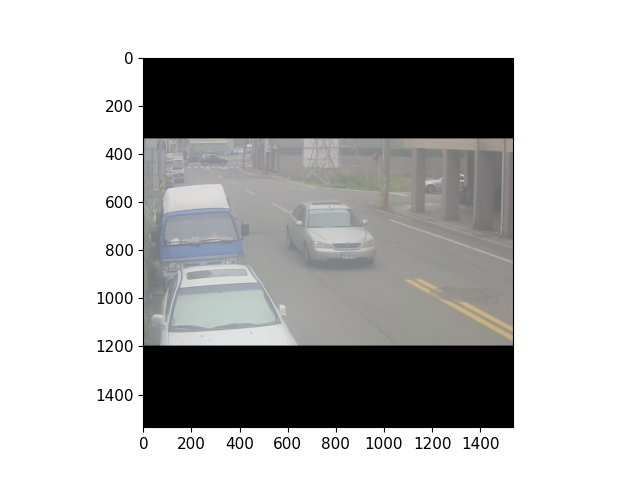

In [12]:
print(img_start.shape)
img_start_np = aug_licence.torchcuda2npy_cv2(copy.deepcopy(img_start)[0])

plt.imshow(img_start_np)


torch.Size([1, 3, 1536, 1536])


<IPython.core.display.Javascript object>


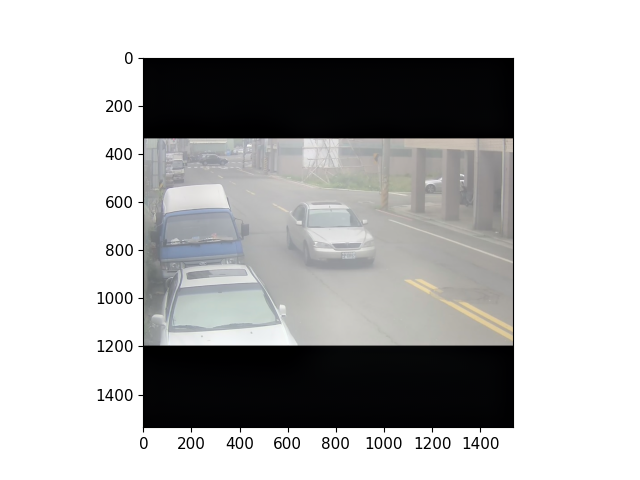

In [13]:
print(direct_img.shape)
direct_img_np = aug_licence.torchcuda2npy_cv2(copy.deepcopy(direct_img)[0])

plt.imshow(direct_img_np)


torch.Size([1, 3, 1536, 1536])


<IPython.core.display.Javascript object>


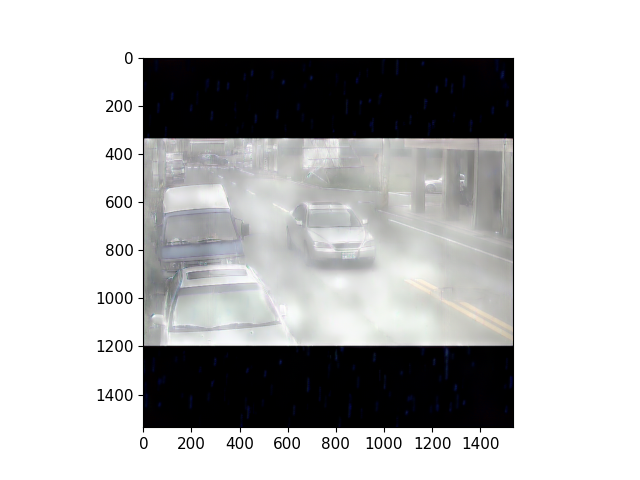

In [14]:
print(img_diffusion_output.shape)
img_diffusion_output_np = aug_licence.torchcuda2npy_cv2(copy.deepcopy(img_diffusion_output)[0])

plt.imshow(img_diffusion_output_np)


In [16]:
for step_t in [100]:
    results_diffusion = {}
    for f in img_paths:
        if f.endswith('.jpg'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            all_img_xt, all_img_x0p, all_noise = run_aug_duffusion_img(img_p,times=step_t)
            break



In [10]:
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont



#for img_ in all_img:
#    print(aug_licence.torchcuda2npy_cv2(img_[0]).shape)
    #Image.fromarray(aug_licence.torchcuda2npy_cv2(img_[0]))
    
img_mix=[]
for ind,_ in enumerate(all_img_xt):
    img_xt = np.uint8(all_img_xt[ind]*255)[400:600,400:650,:]#205 819, 400 650
    img_x0p = np.uint8(all_img_x0p[ind]*255)[400:600,400:650,:]
    mix = np.concatenate((img_xt,img_x0p),axis=0)
    img_mix.append(mix)

#imgs = [Image.fromarray(np.uint8(aug_licence.torchcuda2npy_cv2(img[0])*255)) for img in all_img]
imgs = [Image.fromarray(img) for img in img_mix]

font_path = os.path.join(cv2.__path__[0],'qt','fonts','DejaVuSans.ttf')
myFont = ImageFont.truetype(font_path, size=30)

for ind,_ in enumerate(imgs):
    I1 = ImageDraw.Draw(imgs[ind])
    I1.text((20,20),"step : %d"%ind,fill=(255,255,255),font=myFont)
    I1.text((20,620),"step : %d"%ind,fill=(255,255,255),font=myFont)
    
noise_99 = Image.fromarray(np.uint8(all_noise[99]*255))
#direct_img = Image.fromarray(np.uint8(direct_img*255))
noise_99.save('noise_99.jpg')
#direct_img.save('direct_img.jpg')

# duration is the number of milliseconds between frames; this is 40 frames per second
#imgs[0].save("diffusion_visualize_xt_x0p.gif", save_all=True, append_images=imgs[1:], duration=50, loop=0)
#imgs[0].save('diffusion_visualize_xt_x0p_0.jpg')

In [19]:
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
noise_99 = Image.fromarray(np.uint8(all_noise[99]*255))
#direct_img = Image.fromarray(np.uint8(direct_img*255))

xt_99 = Image.fromarray(np.uint8(all_img_xt[99]*255))
xt_99.save('xt_99.jpg')

x0p_99 = Image.fromarray(np.uint8(all_img_x0p[99]*255))
x0p_99.save('x0p_99.jpg')

x0p_99 = Image.fromarray(np.uint8(all_img_x0p[0]*255))
x0p_99.save('x0p_0.jpg')



In [ ]:
imgs[0].save('diffusion_visualize_xt_x0p_crop_0.jpg')
imgs[9].save('diffusion_visualize_xt_x0p_crop_09.jpg')
imgs[19].save('diffusion_visualize_xt_x0p_crop_19.jpg')
imgs[39].save('diffusion_visualize_xt_x0p_crop_39.jpg')
imgs[59].save('diffusion_visualize_xt_x0p_crop_59.jpg')
imgs[79].save('diffusion_visualize_xt_x0p_crop_79.jpg')
imgs[99].save('diffusion_visualize_xt_x0p_crop_99.jpg')

In [9]:
for step_t in [100]:
    results_diffusion = {}
    for f in img_paths:
        if f.endswith('.jpg'):
            bname = os.path.splitext(f)[0]
            img_p = img_dir + f

            all_img_, all_noise_ = run_aug_img(img_p,times=step_t)
            break


index = 1/100
index = 2/100
index = 3/100
index = 4/100
index = 5/100
index = 6/100
index = 7/100
index = 8/100
index = 9/100
index = 10/100
index = 11/100
index = 12/100
index = 13/100
index = 14/100
index = 15/100
index = 16/100
index = 17/100
index = 18/100
index = 19/100
index = 20/100
index = 21/100
index = 22/100
index = 23/100
index = 24/100
index = 25/100
index = 26/100
index = 27/100
index = 28/100
index = 29/100
index = 30/100
index = 31/100
index = 32/100
index = 33/100
index = 34/100
index = 35/100
index = 36/100
index = 37/100
index = 38/100
index = 39/100
index = 40/100
index = 41/100
index = 42/100
index = 43/100
index = 44/100
index = 45/100
index = 46/100
index = 47/100
index = 48/100
index = 49/100
index = 50/100
index = 51/100
index = 52/100
index = 53/100
index = 54/100
index = 55/100
index = 56/100
index = 57/100
index = 58/100
index = 59/100
index = 60/100
index = 61/100
index = 62/100
index = 63/100
index = 64/100
index = 65/100
index = 66/100
index = 67/100
inde

In [10]:
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont



#for img_ in all_img:
#    print(aug_licence.torchcuda2npy_cv2(img_[0]).shape)
    #Image.fromarray(aug_licence.torchcuda2npy_cv2(img_[0]))
    
img_mix=[]
for ind,_ in enumerate(all_img_):
    img_ = np.uint8(all_img_[ind]*255)#205 819, 400 650
    noise_ = np.uint8(all_noise_[ind]*255)
    mix = np.concatenate((img_,noise_),axis=0)
    img_mix.append(mix)

#imgs = [Image.fromarray(np.uint8(aug_licence.torchcuda2npy_cv2(img[0])*255)) for img in all_img]
imgs = [Image.fromarray(img) for img in img_mix]

font_path = os.path.join(cv2.__path__[0],'qt','fonts','DejaVuSans.ttf')
myFont = ImageFont.truetype(font_path, size=30)

for ind,_ in enumerate(imgs):
    I1 = ImageDraw.Draw(imgs[ind])
    I1.text((20,20),"step : %d"%ind,fill=(255,255,255),font=myFont)
    I1.text((20,620),"step : %d"%ind,fill=(255,255,255),font=myFont)
    
#noise_99 = Image.fromarray(np.uint8(all_noise[99]*255))
#direct_img = Image.fromarray(np.uint8(direct_img*255))
#noise_99.save('noise_99.jpg')
imgs[0].save("diffusion_visualize_img_noise.gif", save_all=True, append_images=imgs[1:], duration=50, loop=0)


In [11]:
print(aug_licence.noiseStepMode)
print(aug_licence.exp_base)
for i in range(100):
    print(1*math.pow(aug_licence.exp_base, i))


exp
0.9120108393559098
1.0
0.9120108393559098
0.8317637711026711
0.7585775750291838
0.6918309709189365
0.6309573444801934
0.575439937337157
0.5248074602497727
0.4786300923226384
0.43651583224016605
0.39810717055349737
0.3630780547701014
0.33113112148259116
0.3019951720402017
0.27542287033381674
0.2511886431509581
0.2290867652767774
0.20892961308540403
0.1905460717963248
0.17378008287493762
0.15848931924611143
0.14454397707459282
0.13182567385564078
0.12022644346174136
0.10964781961431856
0.10000000000000006
0.09120108393559102
0.08317637711026715
0.07585775750291843
0.0691830970918937
0.06309573444801937
0.057543993733715736
0.0524807460249773
0.04786300923226387
0.04365158322401663
0.039810717055349755
0.036307805477010166
0.03311311214825914
0.03019951720402019
0.02754228703338169
0.025118864315095826
0.02290867652767775
0.020892961308540417
0.01905460717963249
0.017378008287493772
0.01584893192461115
0.014454397707459292
0.013182567385564085
0.012022644346174142
0.010964781961431863